# The Perceptron

### What is a Perceptron?

The **Perceptron** is the simplest type of artificial neural network and serves as a fundamental linear binary classifier. It mimics a biological neuron by taking input signals, weighting them, and passing them through an activation function—specifically the sign function—to determine a class label (1 or −1).

Mathematically, the pre-activation is given by:

$$z = w_1x_1 + w_2x_2 + ... + w_nx_n + b$$

The neuron "fires" based on whether $z \geq 0$.




### Inital Implemetation with Iris dataset

We can use the perceptron on the Iris dataset, focusing on two types that are linearly separable: Setosa and Versicolor



df.iloc[:100]
    sepal_length  sepal_width  petal_length  petal_width     species
0            5.1          3.5           1.4          0.2      setosa
1            4.9          3.0           1.4          0.2      setosa
2            4.7          3.2           1.3          0.2      setosa
3            4.6          3.1           1.5          0.2      setosa
4            5.0          3.6           1.4          0.2      setosa
..           ...          ...           ...          ...         ...
95           5.7          3.0           4.2          1.2  versicolor
96           5.7          2.9           4.2          1.3  versicolor
97           6.2          2.9           4.3          1.3  versicolor
98           5.1          2.5           3.0          1.1  versicolor
99           5.7          2.8           4.1          1.3  versicolor

[100 rows x 5 columns]

Target Labels (y):
[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -

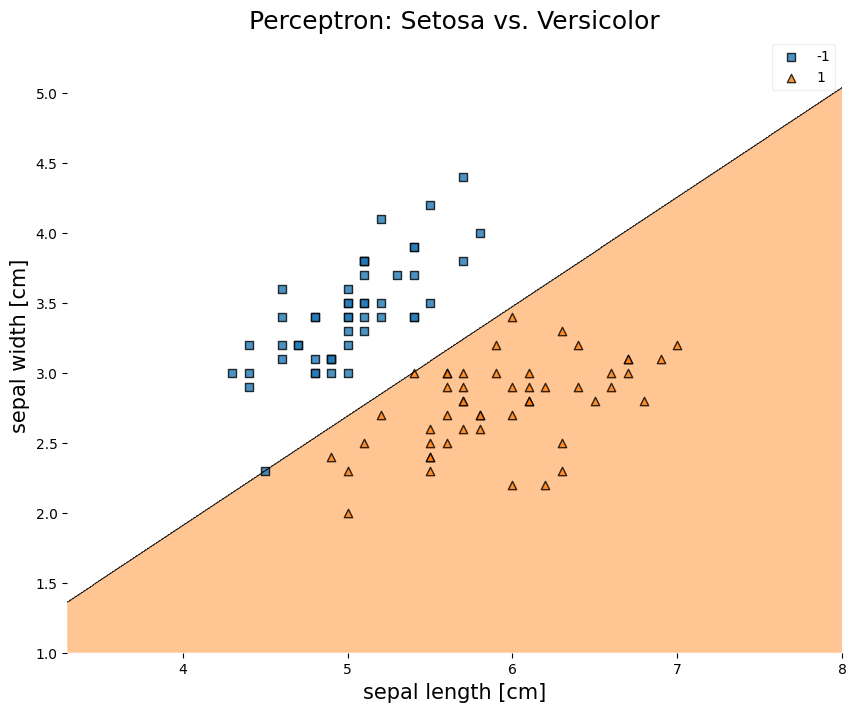

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

# Load and Preprocess
df_iris = pd.read_csv("https://raw.githubusercontent.com/RandyRDavila/Data_Science_and_Machine_Learning_Spring_2022/main/Lecture_3/Datasets/iris_dataset.csv")
y_iris = df_iris.iloc[0:100].species.values
y_iris = np.where(y_iris == 'setosa', -1, 1)
X_iris = df_iris[["sepal_length", "sepal_width"]].iloc[:100].values

print("df.iloc[:100]")
print(df_iris.iloc[:100])

# Store and convert species values
y_iris = df_iris.iloc[0:100].species.values
# Convert setosa to -1 and others to 1 (The Array math)
y_iris = np.where(y_iris == 'setosa', -1, 1)

# Store feature measurements
X_iris = df_iris[["sepal_length", "sepal_width"]].iloc[:100].values

# Show the array (The Array Output)
print("\nTarget Labels (y):")
print(y_iris)

class Perceptron(object):

    def __init__(self, eta = .5, epochs=50):
        self.eta = eta
        self.epochs = epochs

    def train(self, X, y):
        self.w_ = np.random.rand(1 + X.shape[1])
        self.errors_ = []
        for _ in range(self.epochs):
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (self.predict(xi) - target)
                self.w_[:-1] -= update*xi
                self.w_[-1] -= update
                errors += int(update != 0)
            if errors == 0:
                return self
            self.errors_.append(errors)
        return self

    def net_input(self, X):
        return np.dot(X, self.w_[:-1]) + self.w_[-1]

    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, -1)

# Training on Iris
percep_iris = Perceptron(epochs = 1000)
percep_iris.train(X_iris, y_iris)
# Check if predictions match
y_hat_iris = percep_iris.predict(X_iris)
print(f"Iris Predictions Correct? {np.array_equal(y_iris, y_hat_iris)}")

# visualize the 'Iris Perceptron' Decision Boundary
plt.figure(figsize = (10, 8))
plot_decision_regions(X_iris, y_iris, clf = percep_iris)
plt.title("Perceptron: Setosa vs. Versicolor", fontsize = 18)
plt.xlabel("sepal length [cm]", fontsize = 15)
plt.ylabel("sepal width [cm]", fontsize = 15)
plt.show()


Compare y_iris == y_hat_iris:
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True]


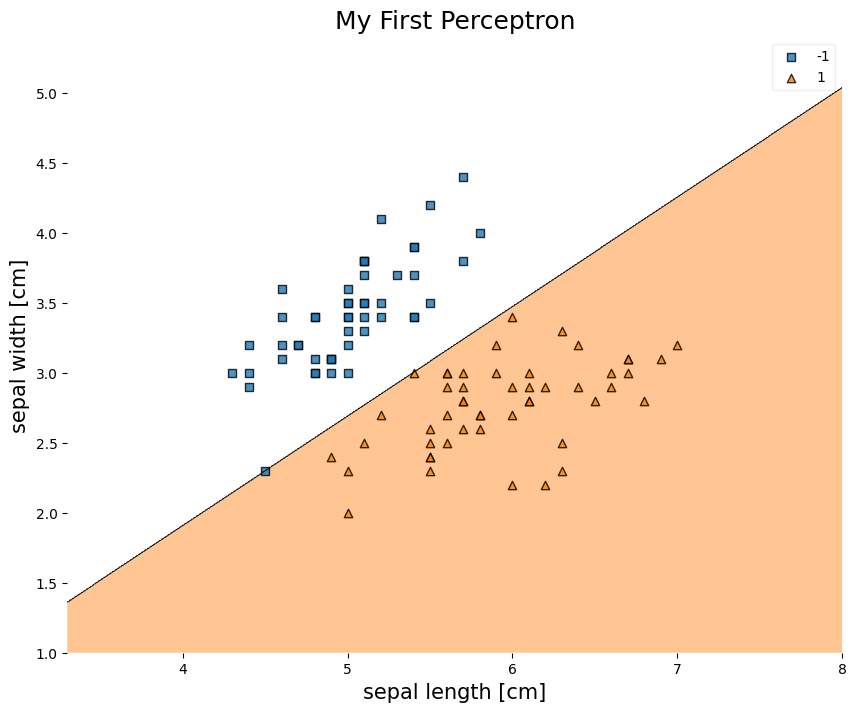

In [8]:
# Predict labels on the features in X
y_hat_iris = percep_iris.predict(X_iris)

# Compare y_hat and y
print("\nCompare y_iris == y_hat_iris:")
print(y_iris == y_hat_iris)

# Visualize the decision boundary
plt.figure(figsize = (10, 8))
plot_decision_regions(X_iris, y_iris, clf = percep_iris)
plt.title("My First Perceptron", fontsize = 18)
plt.xlabel("sepal length [cm]", fontsize = 15)
plt.ylabel("sepal width [cm]", fontsize = 15)
plt.show()


Using `plot_decision_regions`, we can see the clear line the model discovered to separate the species. Since the data is linearly separable, the error eventually drops to zero.

### Using the Palmer Penguins Dataset

Now, we apply the same logic to a more complex dataset: Palmer Penguins. We will try to classify whether a penguin is an Adelie or Chinstrap based on their bill measurements.

Penguin Model Accuracy: 87.85%


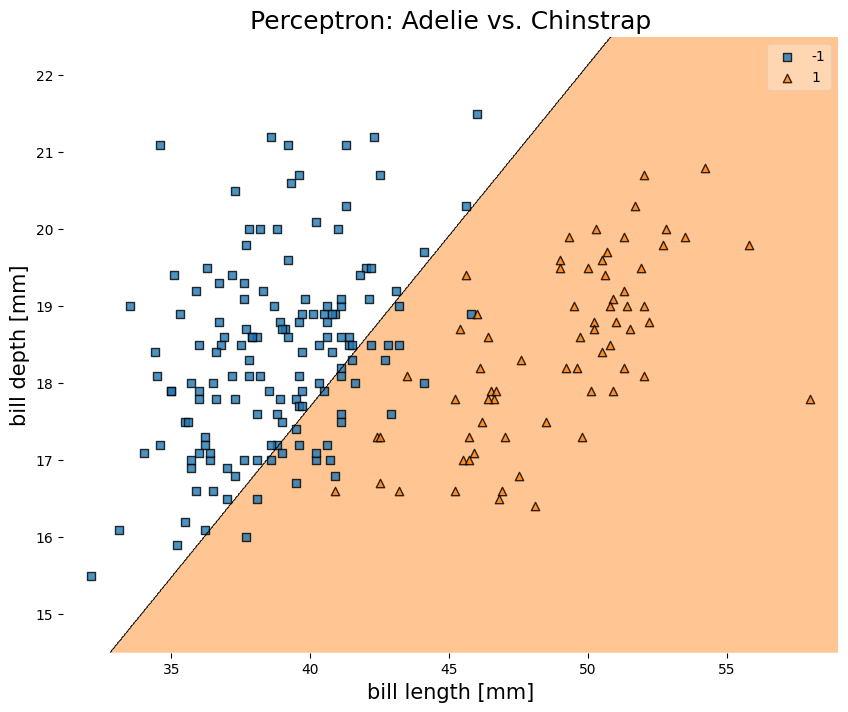

In [9]:
# Load Penguins
df_penguins = sns.load_dataset("penguins").dropna()
# Filter for two species
df_binary = df_penguins[df_penguins['species'].isin(['Adelie', 'Chinstrap'])]

X_pen = df_binary[['bill_length_mm', 'bill_depth_mm']].values
y_pen = np.where(df_binary['species'] == 'Adelie', -1, 1)

# Training
percep_pen = Perceptron(eta=0.01, epochs=500)
percep_pen.train(X_pen, y_pen)

# print accuracy
y_hat_pen = percep_pen.predict(X_pen)
accuracy = (y_pen == y_hat_pen).mean()
print(f"Penguin Model Accuracy: {accuracy * 100:.2f}%")

# viisualize the 'Penguin Perceptron' Decision Boundary
plt.figure(figsize = (10, 8))
plot_decision_regions(X_pen, y_pen, clf = percep_pen)
plt.title("Perceptron: Adelie vs. Chinstrap", fontsize = 18)
plt.xlabel("bill length [mm]", fontsize = 15)
plt.ylabel("bill depth [mm]", fontsize = 15)
plt.show()

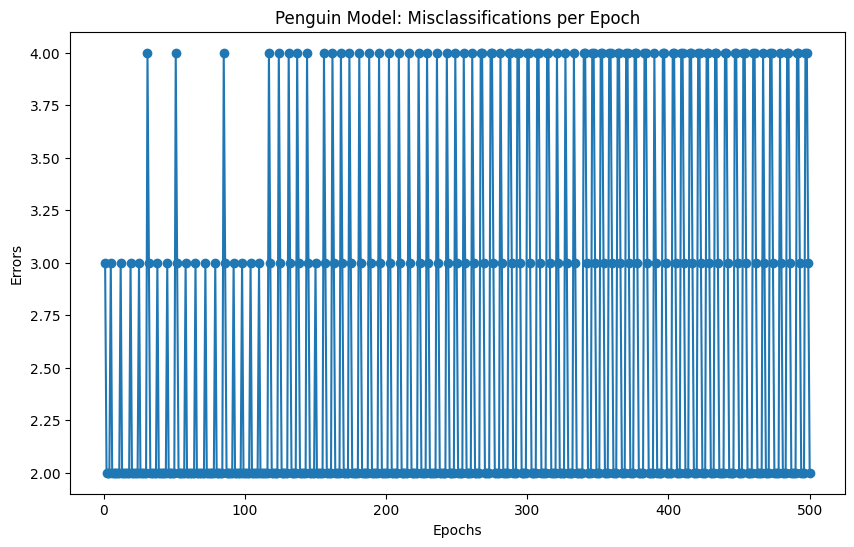

In [10]:
#Analysing convergence (error plot)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(percep_pen.errors_) + 1), percep_pen.errors_, marker='o')
plt.title("Penguin Model: Misclassifications per Epoch")
plt.xlabel("Epochs")
plt.ylabel("Errors")
plt.show()

### Findings

Through implementing a Perceptron from scratch on the Iris and Penguins datasets, I observed the model's fundamental reliance on linear separability. While the Iris model converged to 100% accuracy, the Penguin model reached 87.85% because of natural feature overlap between species. The resulting oscillation in the error plots and the imperfect decision boundaries highlight the Perceptron's limitations with non-linearly separable data, suggesting that more complex models are required for real-world datasets